In [1]:
%load_ext autoreload
%autoreload 2

#recharge tout seul le notebook (2prmiere lignes)
    
import numpy as np
import scipy as sp
#import pyccl as ccl
import math
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from scipy import integrate
from functools import partial
from scipy.integrate import quad, dblquad

import pyccl as ccl
import camb
from camb import model, initialpower
import cosmology

import fisher_matrix_local_png
import fisher_matrix_bao_SuEisenstein
import fisher_matrix_rsd
import fisher_matrix_neutrino_mass

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

In [9]:
N_zm_u = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_udropout_highz.npz')
N_zm_g = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_gdropout.npz')
N_zm_r = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_rdropout.npz')
samples = [N_zm_u, N_zm_g, N_zm_r]

In [10]:
N_zm_u['surface_deg2']

array(1.67)

In [11]:
import sys
sys.path.append('../forecasts/')
import bias_model

import fisher_matrix_local_png
import fisher_matrix_bao_SuEisenstein
import fisher_matrix_rsd
import fisher_matrix_neutrino_mass

from itertools import product
import numpy as np
def linear_bias(redshift, mag, tracer = 'BG_faint'):

    if tracer == 'BG_faint' or tracer == 'BG_bright': return bias_model.bias_bg(redshift, mag)
    if tracer == 'ELG': return bias_model.bias_elg(redshift, mag)
    if tracer == 'LRG': return bias_model.bias_lrg(redshift, mag)
    if tracer == 'QSO': return bias_model.bias_qso(redshift, mag)
    if tracer == 'LBGu': return bias_model.bias_lbg(redshift, mag)
    if tracer == 'LBGg': return bias_model.bias_lbg(redshift, mag)
    if tracer == 'LBGr': return bias_model.bias_lbg(redshift, mag)
        
    return np.ones(len(redshift))

5544.9101796407185
Building CAMB interpolators...
Done.
2857.4850299401196
Building CAMB interpolators...
Done.
577.245508982036
Building CAMB interpolators...
Done.


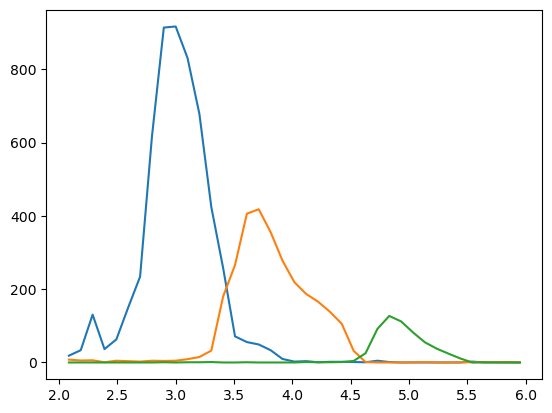

In [12]:
mag_max = [25.2,25.2,25.2]
bias = [3,4,5]
Area = 18000
constraints_fnl = []
constraints_bao = []
constraints_neutrino = []
constraints_rsd = []
for i, s in enumerate(samples):
    sample = samples[i]
    z_centers, mag_centers =  sample['z_center'], sample['mag_center'] 
    zarray = z_centers[z_centers > 2]
    n_zm_target = sample['object_count']/sample['surface_deg2']
    n_zm_target[:,(mag_centers > mag_max[i])] = 0
    nz = np.sum(n_zm_target, axis=1)[z_centers > 2]
    plt.plot(zarray, nz)
    N_degm2 = np.sum(nz)
    print(N_degm2)
    bz = bias[i] * np.ones(len(z_centers))[z_centers > 2]

    A,B,c,d=fisher_matrix_local_png.sigma_fnl_single_tracer(zarray,nz,bz,Area,N_degm2,Deltaz=0.5,p=1,mod='bbks',kmax=0.1,cosmo=cosmo)
    constraints_fnl.append([A,B,c,d])
    
    A,B,C,d,e,f=fisher_matrix_bao_SuEisenstein.sigma_Da_H_single_tracer(zarray,nz,bz,Area,N_degm2,Deltaz=0.5,cosmo=cosmo)
    constraints_bao.append([A,B,C,d,e,f])

    list_zbin, list_sigma_b, list_sigma_mnu, zeff, sigma_b_eff, sigma_mnu_eff=fisher_matrix_neutrino_mass.sigma_mnu_single_tracer(zarray,nz,bz,Area,N_degm2,Deltaz=0.5,kmax=0.1,cosmo=cosmo)
    constraints_neutrino.append([list_zbin, list_sigma_b, list_sigma_mnu, zeff, sigma_b_eff, sigma_mnu_eff])

    list_zbin, list_sigma_bs8, list_sigma_fs8, zeff, sigma_bs8_eff, sigma_fs8_eff=fisher_matrix_rsd.sigma_rsd_single_tracer(zarray,nz,bz,Area,N_degm2,Deltaz=0.5,kmax=0.1,cosmo=cosmo)
    constraints_rsd.append([list_zbin, list_sigma_bs8, list_sigma_fs8, zeff, sigma_bs8_eff, sigma_fs8_eff])

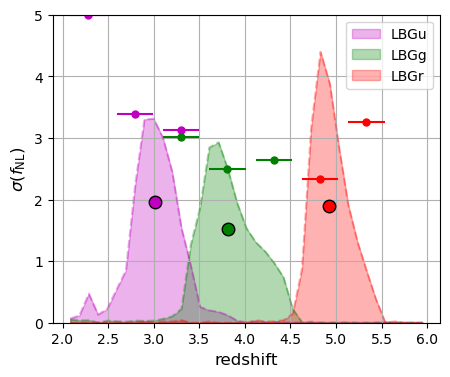

In [13]:
mag_max = [25.2,25.2,25.2]
bias = [3,4,5]
color = ['m', 'g', 'r']
label = ['LBGu', 'LBGg', 'LBGr']
plt.figure(figsize=(5, 4))
for i, s in enumerate(samples):

    sample = samples[i]
    z_centers, mag_centers =  sample['z_center'], sample['mag_center'] 
    zarray = z_centers[z_centers > 2]
    S = 1.6
    S_survey = 18000
    time_one_pass = 15 # minutes
    n_zm_target = sample['object_count']/sample['surface_deg2']
    n_zm_target[:,(mag_centers > mag_max[i])] = 0
    nz = np.sum(n_zm_target, axis=1)[z_centers > 2]
    N_degm2 = np.sum(nz)

    list_zbin, list_sigma_fnl, zeff, sigma_fnl_eff  = constraints_fnl[i]

    plt.errorbar(list_zbin,list_sigma_fnl, xerr=0.2
                 , marker='o', linestyle='', color=color[i], markersize=5,)

    plt.errorbar(zeff,sigma_fnl_eff
                 , marker='o', linestyle='', color=color[i], markersize=9,markeredgecolor='k')
    
    plt.fill_between(zarray, 20*nz/np.trapezoid(nz), 0*nz/np.trapezoid(nz),  color=color[i], alpha=0.3, label = label[i])
    plt.plot(zarray, 20*nz/np.trapezoid(nz), '--',  color=color[i], alpha=0.3)
    
plt.ylim(0, 5)
plt.grid(True)
plt.ylabel(r'$\sigma(f_{\rm NL})$',fontsize=12)
plt.xlabel(r'redshift',fontsize=12)
plt.legend()
plt.savefig(f'../figures/forecast_dark_time_fNL.png', dpi = 300, bbox_inches='tight' )

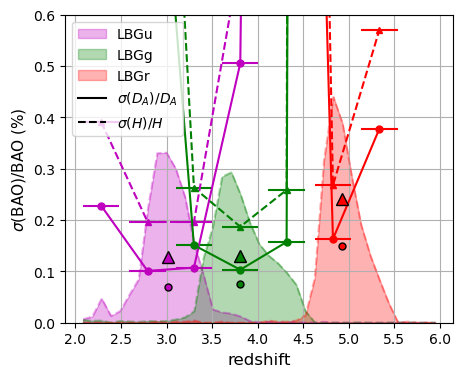

In [14]:
mag_max = [25.2,25.2,25.2]
bias = [3,4,5]
color = ['m', 'g', 'r']
label = ['LBGu', 'LBGg', 'LBGr']
plt.figure(figsize=(5, 4))
for i, s in enumerate(samples):

    sample = samples[i]
    z_centers, mag_centers =  sample['z_center'], sample['mag_center'] 
    zarray = z_centers[z_centers > 2]
    S = 1.6
    S_survey = 18000
    time_one_pass = 15 # minutes
    n_zm_target = sample['object_count']/sample['surface_deg2']
    n_zm_target[:,(mag_centers > mag_max[i])] = 0
    nz = np.sum(n_zm_target, axis=1)[z_centers > 2]
    N_degm2 = np.sum(nz)

    list_zbin, list_sigma_Da,list_sigma_H, zeff, sigma_Da_eff, sigma_H_eff  = constraints_bao[i]

    plt.errorbar(list_zbin,100*np.array(list_sigma_Da), xerr=0.2
                 , marker='o', linestyle='-', color=color[i], markersize=5,)

    plt.errorbar(zeff,100*sigma_Da_eff
                 , marker='o', linestyle='', color=color[i], markersize=5,markeredgecolor='k')

    plt.errorbar(list_zbin,100*np.array(list_sigma_H), xerr=0.2
                 , marker='^', linestyle='--', color=color[i], markersize=5,)

    plt.errorbar(zeff,100*sigma_H_eff
                 , marker='^', linestyle='', color=color[i], markersize=9,markeredgecolor='k')
    
    plt.fill_between(zarray, 2*nz/np.trapezoid(nz), 0*nz/np.trapezoid(nz),  color=color[i], alpha=0.3, label = label[i])
    plt.plot(zarray, 2*nz/np.trapezoid(nz), '--',  color=color[i], alpha=0.3)
plt.plot([], [], '-k', label = r'$\sigma(D_A)/D_A$', )
plt.plot([], [], '--k', label = r'$\sigma(H)/H$', )
plt.ylim(0, 0.6)
plt.grid(True)
plt.ylabel(r'$\sigma$(BAO)/BAO $(\%)$',fontsize=11)
plt.xlabel(r'redshift',fontsize=12)
plt.legend()
plt.savefig(f'../figures/forecast_dark_time_BAO.png', dpi = 300, bbox_inches='tight' )

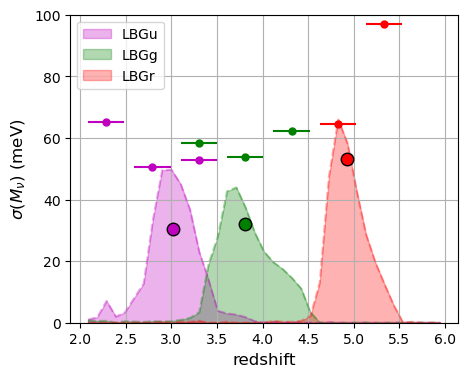

In [15]:
mag_max = [25.2,25.2,25.2]
bias = [3,4,5]
color = ['m', 'g', 'r']
label = ['LBGu', 'LBGg', 'LBGr']
plt.figure(figsize=(5, 4))
for i, s in enumerate(samples):

    sample = samples[i]
    z_centers, mag_centers =  sample['z_center'], sample['mag_center'] 
    zarray = z_centers[z_centers > 2]
    S = 1.6
    S_survey = 18000
    time_one_pass = 15 # minutes
    n_zm_target = sample['object_count']/sample['surface_deg2']
    n_zm_target[:,(mag_centers > mag_max[i])] = 0
    nz = np.sum(n_zm_target, axis=1)[z_centers > 2]
    N_degm2 = np.sum(nz)

    list_zbin, list_sigma_b, list_sigma_mnu, zeff, sigma_b_eff, sigma_mnu_eff  = constraints_neutrino[i]

    plt.errorbar(list_zbin,1000*np.array(list_sigma_mnu), xerr=0.2
                 , marker='o', linestyle='', color=color[i], markersize=5,)

    plt.errorbar(zeff,1000*sigma_mnu_eff
                 , marker='o', linestyle='', color=color[i], markersize=9,markeredgecolor='k')
    
    plt.fill_between(zarray, 300*nz/np.trapezoid(nz), 0*nz/np.trapezoid(nz),  color=color[i], alpha=0.3, label = label[i])
    plt.plot(zarray, 300*nz/np.trapezoid(nz), '--',  color=color[i], alpha=0.3)
plt.ylim(0, 100)
plt.grid(True)
plt.ylabel(r'$\sigma(M_\nu)$ (meV)',fontsize=12)
plt.xlabel(r'redshift',fontsize=12)
plt.legend()
plt.savefig(f'../figures/forecast_dark_time_neutrino.png', dpi = 300, bbox_inches='tight' )

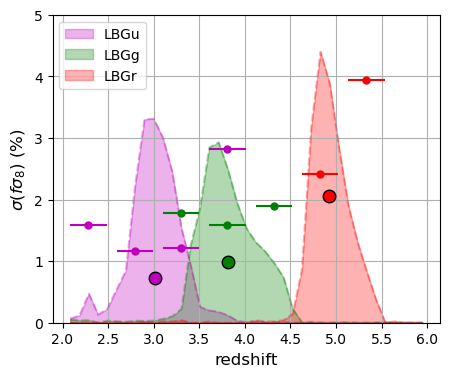

In [16]:
mag_max = [25.2,25.2,25.2]
bias = [3,4,5]
color = ['m', 'g', 'r']
label = ['LBGu', 'LBGg', 'LBGr']
plt.figure(figsize=(5, 4))
for i, s in enumerate(samples):

    sample = samples[i]
    z_centers, mag_centers =  sample['z_center'], sample['mag_center'] 
    zarray = z_centers[z_centers > 2]
    S = 1.6
    S_survey = 18000
    time_one_pass = 15 # minutes
    n_zm_target = sample['object_count']/sample['surface_deg2']
    n_zm_target[:,(mag_centers > mag_max[i])] = 0
    nz = np.sum(n_zm_target, axis=1)[z_centers > 2]
    N_degm2 = np.sum(nz)

    list_zbin, list_sigma_bs8, list_sigma_fs8, zeff, sigma_bs8_eff, sigma_fs8_eff=constraints_rsd[i]

    plt.errorbar(list_zbin,100*np.array(list_sigma_fs8), xerr=0.2
                 , marker='o', linestyle='', color=color[i], markersize=5,)

    plt.errorbar(zeff,100*sigma_fs8_eff
                 , marker='o', linestyle='', color=color[i], markersize=9,markeredgecolor='k')
    
    plt.fill_between(zarray, 20*nz/np.trapezoid(nz), 0*nz/np.trapezoid(nz),  color=color[i], alpha=0.3, label = label[i])
    plt.plot(zarray, 20*nz/np.trapezoid(nz), '--',  color=color[i], alpha=0.3)
plt.ylim(0, 5)
plt.grid(True)
plt.ylabel(r'$\sigma(f\sigma_8)$ $(\%)$',fontsize=12)
plt.xlabel(r'redshift',fontsize=12)
plt.legend()
plt.savefig(f'../figures/forecast_dark_time_fsigma8.png', dpi = 300, bbox_inches='tight' )